<a href="https://colab.research.google.com/github/beecall17/Fuse-AI-Fellowship/blob/main/Neural%20Network%20%5BWeek%2009%5D/Neural_network_assignmnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# !pip install optuna

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score
# import optuna
import warnings
warnings.filterwarnings('ignore')

In [5]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Pytorch version: {torch.__version__}")

Using device: cuda
Pytorch version: 2.11.0+cu128


NN Foundations
1. Simple two layered nn

In [6]:
class SimpleTwoLayerNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(SimpleTwoLayerNN, self).__init__()
    self.layer1 = nn.Linear(input_size, hidden_size)
    self.layer2 = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    x = self.layer1(x)
    x = torch.relu(x)
    x = self.layer2(x)
    return x

In [7]:
model_test = SimpleTwoLayerNN(10, 20, 3)
model_test.to(device)

SimpleTwoLayerNN(
  (layer1): Linear(in_features=10, out_features=20, bias=True)
  (layer2): Linear(in_features=20, out_features=3, bias=True)
)

2. Activation functions: Relu vs Sigmoid

In [8]:
# Loading fake dataset.
from torch.utils.data import TensorDataset
# Standard input size of Image
INPUT_SIZE = 3*32*32

X_fake = torch.randn(100, INPUT_SIZE)
y_fake = torch.randint(0, 10, (100,))

fake_dataset = TensorDataset(X_fake, y_fake)

train_fake, val_fake = random_split(fake_dataset, [80, 20])
train_loader = DataLoader(train_fake, batch_size=32, shuffle=True)
val_loader = DataLoader(val_fake, batch_size=32, shuffle=False)


In [9]:
from torch.autograd import no_grad
# Sigmoid activation epoch loss check

class SigmoidTwoLayerNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(SigmoidTwoLayerNN, self).__init__()
    self.layer1 = nn.Linear(input_size, hidden_size)
    self.layer2 = nn.Linear(hidden_size, output_size)

  def forward(self, x):
      x = self.layer1(x)
      x = torch.sigmoid(x)
      x = self.layer2(x)
      return x

  def train_and_evaluate(self, train_loader, val_loader, criterion, optimizer):

      # loss store
      train_losses = []
      val_losses = []

      no_of_epochs = 20

      for epoch in range(no_of_epochs):
          # Training begins
          self.train()
          train_epoch_loss = 0.0
          for input, label in train_loader:
              input, label = input.to(device), label.to(device)

              output = self(input)
              loss = criterion(output, label)

              optimizer.zero_grad()
              loss.backward()
              optimizer.step()

              train_epoch_loss += loss.item() * input.size(0)
          train_epoch_loss /= len(train_loader.dataset)
          train_losses.append(train_epoch_loss)

          # Validation begin
          self.eval()
          with no_grad():
              val_epoch_loss = 0.0
              for input, label in val_loader:
                  input, label = input.to(device), label.to(device)
                  output = self(input)
                  loss = criterion(output,label)

                  val_epoch_loss += loss.item() * input.size(0)


              val_epoch_loss /= len(val_loader.dataset)
              val_losses.append(val_epoch_loss)

          print(f"Epoch {epoch+1}/{no_of_epochs}, Train Loss: {train_epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}")
      return train_losses, val_losses
sigmoid_inst = SigmoidTwoLayerNN(INPUT_SIZE, 20, 10)
sigmoid_inst.to(device)
sig_train_loss , sig_val_loss = sigmoid_inst.train_and_evaluate(train_loader, val_loader, nn.CrossEntropyLoss(), optim.Adam(sigmoid_inst.parameters(), lr=0.001))

Epoch 1/20, Train Loss: 2.4021, Val Loss: 2.2032
Epoch 2/20, Train Loss: 2.0740, Val Loss: 2.2023
Epoch 3/20, Train Loss: 1.8655, Val Loss: 2.2031
Epoch 4/20, Train Loss: 1.7289, Val Loss: 2.2039
Epoch 5/20, Train Loss: 1.6320, Val Loss: 2.2054
Epoch 6/20, Train Loss: 1.5620, Val Loss: 2.2071
Epoch 7/20, Train Loss: 1.5101, Val Loss: 2.2084
Epoch 8/20, Train Loss: 1.4686, Val Loss: 2.2096
Epoch 9/20, Train Loss: 1.4348, Val Loss: 2.2106
Epoch 10/20, Train Loss: 1.4044, Val Loss: 2.2115
Epoch 11/20, Train Loss: 1.3778, Val Loss: 2.2124
Epoch 12/20, Train Loss: 1.3529, Val Loss: 2.2131
Epoch 13/20, Train Loss: 1.3295, Val Loss: 2.2142
Epoch 14/20, Train Loss: 1.3068, Val Loss: 2.2151
Epoch 15/20, Train Loss: 1.2844, Val Loss: 2.2154
Epoch 16/20, Train Loss: 1.2635, Val Loss: 2.2159
Epoch 17/20, Train Loss: 1.2422, Val Loss: 2.2163
Epoch 18/20, Train Loss: 1.2222, Val Loss: 2.2168
Epoch 19/20, Train Loss: 1.2021, Val Loss: 2.2174
Epoch 20/20, Train Loss: 1.1825, Val Loss: 2.2179


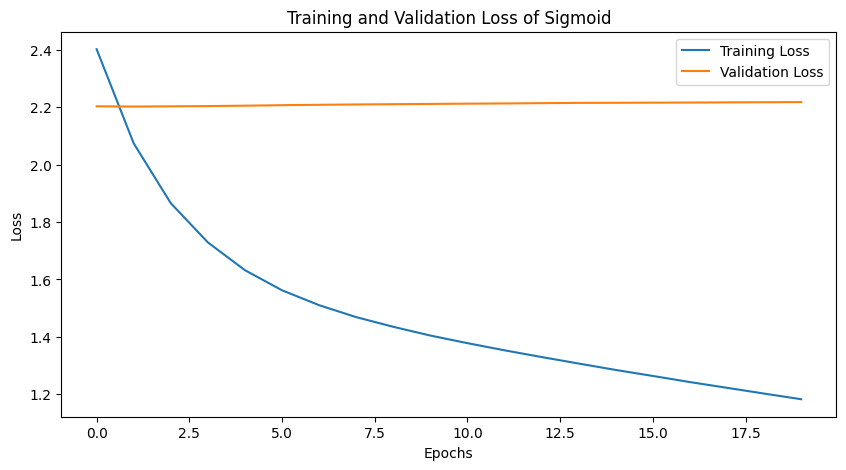

In [10]:
from matplotlib import axes
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sig_train_loss, label='Training Loss')
ax.plot(sig_val_loss, label='Validation Loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss of Sigmoid')
ax.legend()
plt.show()

In [11]:
# relu activation epoch loss check
class ReluNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(ReluNN, self).__init__()
    self.layer1 = nn.Linear(input_size, hidden_size)
    self.layer2 = nn.Linear(hidden_size, output_size)

  def forward(self, x):
      x = self.layer1(x)
      x = torch.relu(x)
      x = self.layer2(x)
      return x

  def train_and_evaluate(self, train_loader, val_loader, criterion, optimizer):

      # loss store
      train_losses = []
      val_losses = []

      no_of_epochs = 20

      for epoch in range(no_of_epochs):
          # Training begins
          self.train()
          train_epoch_loss = 0.0
          for input, label in train_loader:
              input, label = input.to(device), label.to(device)

              output = self(input)
              loss = criterion(output, label)

              optimizer.zero_grad()
              loss.backward()
              optimizer.step()

              train_epoch_loss += loss.item() * input.size(0)
          train_epoch_loss /= len(train_loader.dataset)
          train_losses.append(train_epoch_loss)

          # Validation begin
          self.eval()
          with no_grad():
              val_epoch_loss = 0.0
              for input, label in val_loader:
                  input, label = input.to(device), label.to(device)
                  output = self(input)
                  loss = criterion(output,label)

                  val_epoch_loss += loss.item() * input.size(0)


              val_epoch_loss /= len(val_loader.dataset)
              val_losses.append(val_epoch_loss)

          print(f"Epoch {epoch+1}/{no_of_epochs}, Train Loss: {train_epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}")
      return train_losses, val_losses
relu_inst = ReluNN(INPUT_SIZE, 20, 10)
relu_inst.to(device)
relu_train_loss , relu_val_loss = relu_inst.train_and_evaluate(train_loader, val_loader, nn.CrossEntropyLoss(), optim.Adam(relu_inst.parameters(), lr=0.001))

Epoch 1/20, Train Loss: 2.3404, Val Loss: 2.3890
Epoch 2/20, Train Loss: 1.7500, Val Loss: 2.4005
Epoch 3/20, Train Loss: 1.4375, Val Loss: 2.4064
Epoch 4/20, Train Loss: 1.1942, Val Loss: 2.4081
Epoch 5/20, Train Loss: 0.9991, Val Loss: 2.4067
Epoch 6/20, Train Loss: 0.8351, Val Loss: 2.4047
Epoch 7/20, Train Loss: 0.7037, Val Loss: 2.4022
Epoch 8/20, Train Loss: 0.5864, Val Loss: 2.4008
Epoch 9/20, Train Loss: 0.4963, Val Loss: 2.3998
Epoch 10/20, Train Loss: 0.4167, Val Loss: 2.3975
Epoch 11/20, Train Loss: 0.3545, Val Loss: 2.3946
Epoch 12/20, Train Loss: 0.3009, Val Loss: 2.3926
Epoch 13/20, Train Loss: 0.2510, Val Loss: 2.3914
Epoch 14/20, Train Loss: 0.2107, Val Loss: 2.3906
Epoch 15/20, Train Loss: 0.1768, Val Loss: 2.3898
Epoch 16/20, Train Loss: 0.1511, Val Loss: 2.3889
Epoch 17/20, Train Loss: 0.1280, Val Loss: 2.3890
Epoch 18/20, Train Loss: 0.1060, Val Loss: 2.3892
Epoch 19/20, Train Loss: 0.0909, Val Loss: 2.3893
Epoch 20/20, Train Loss: 0.0768, Val Loss: 2.3893


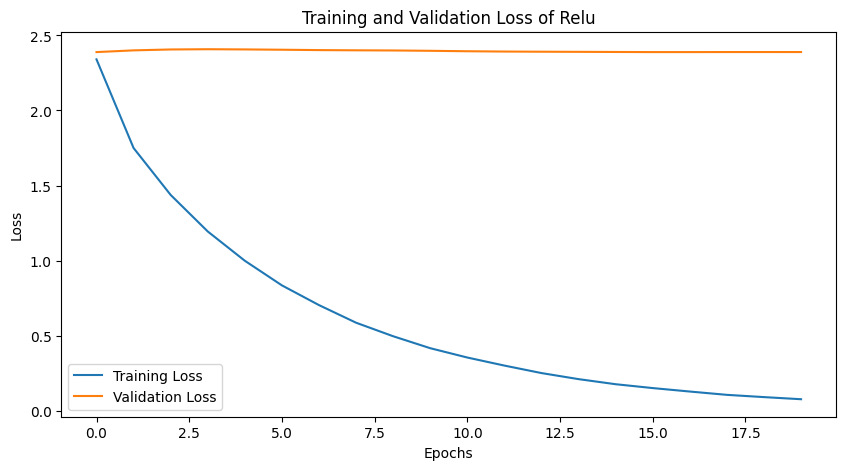

In [12]:
from matplotlib import axes
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(relu_train_loss, label='Training Loss')
ax.plot(relu_val_loss, label='Validation Loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss of Relu')
ax.legend()
plt.show()

Comparison between Sigmoid and ReLU:

* Learning Speed and Convergence: The ReLU model's training loss drops much faster and reaches a lower value than the sigmoid model's training loss. This is typical, as ReLU (and its variants) often mitigate the vanishing gradient problem, allowing for more efficient training in deeper networks.
* Generalization (Validation Loss): The ReLU model achieves a lower and more stable validation loss (~~2.26) compared to the sigmoid model (~2.44). While both models show signs of overfitting (training loss goes very low, while validation loss plateaus or slightly increases), the ReLU model's validation performance is notably better. This suggests that the ReLU activation function, in this case, helps the model to generalize better to unseen data.
* Overfitting: Both models exhibit a gap between training and validation loss, indicating some degree of overfitting. The training loss keeps dropping significantly, while the validation loss stops improving or slightly increases. The sigmoid model shows a much more pronounced difference between its very low training loss and its very high, flat validation loss, indicating more severe overfitting or a less effective learning process on the validation set.

In conclusion, the ReLU activation function appears to be more effective for this specific task and network architecture, leading to faster learning and better generalization performance than the sigmoid activation function, even though both still suffer from overfitting to some extent on this small dataset.

Loss function choice: train with nn.CrossEntropyLoss.
Why is this preferred over nn.MSELoss for multi-class defect classification?

MSELoss is for regression problems to calculating loss for continus or discreet moving values.
Whereas, CrossEntropyLoss usis Log(loss) which provides the probaility of that class. This total of corssentropy loss is always 1 and it cannot be negative which helps to classify the prediciton class effectively.

Optimizer comparison: train the same network three
times — torch.optim.SGD, SGD with momentum=0.9, and Adam. Plot all three loss
curves on one graph. Which converges fastest? Estimate the GPU memory each
optimizer requires for this model.

In [13]:
optimizer_configs = [
    ("SGD", optim.SGD, {"lr": 0.01}),
    ("SGD_m", optim.SGD, {"lr": 0.01, "momentum": 0.9}),
    ("Adam", optim.Adam, {"lr": 0.001})
]

all_train_loss = {}
all_val_loss = {}

for name, optimizer_class, optimizer_kwargs in optimizer_configs:

    criterion = nn.CrossEntropyLoss()

    # Initialize a new model for each optimizer
    relu_inst = ReluNN(INPUT_SIZE, 20, 10)
    relu_inst.to(device)

    # Initialize the optimizer with the new model's parameters
    optimizer_instance = optimizer_class(relu_inst.parameters(), **optimizer_kwargs)

    train_losses, val_losses = relu_inst.train_and_evaluate(train_loader, val_loader, criterion, optimizer_instance)
    all_train_loss[name] = train_losses
    all_val_loss[name] = val_losses

Epoch 1/20, Train Loss: 2.3463, Val Loss: 2.2762
Epoch 2/20, Train Loss: 2.1922, Val Loss: 2.2775
Epoch 3/20, Train Loss: 2.0617, Val Loss: 2.2779
Epoch 4/20, Train Loss: 1.9598, Val Loss: 2.2784
Epoch 5/20, Train Loss: 1.8752, Val Loss: 2.2796
Epoch 6/20, Train Loss: 1.8018, Val Loss: 2.2811
Epoch 7/20, Train Loss: 1.7341, Val Loss: 2.2821
Epoch 8/20, Train Loss: 1.6682, Val Loss: 2.2839
Epoch 9/20, Train Loss: 1.6048, Val Loss: 2.2856
Epoch 10/20, Train Loss: 1.5459, Val Loss: 2.2862
Epoch 11/20, Train Loss: 1.4876, Val Loss: 2.2885
Epoch 12/20, Train Loss: 1.4324, Val Loss: 2.2902
Epoch 13/20, Train Loss: 1.3789, Val Loss: 2.2923
Epoch 14/20, Train Loss: 1.3276, Val Loss: 2.2943
Epoch 15/20, Train Loss: 1.2770, Val Loss: 2.2957
Epoch 16/20, Train Loss: 1.2269, Val Loss: 2.2974
Epoch 17/20, Train Loss: 1.1780, Val Loss: 2.2989
Epoch 18/20, Train Loss: 1.1296, Val Loss: 2.3001
Epoch 19/20, Train Loss: 1.0842, Val Loss: 2.3017
Epoch 20/20, Train Loss: 1.0413, Val Loss: 2.3036
Epoch 1/2

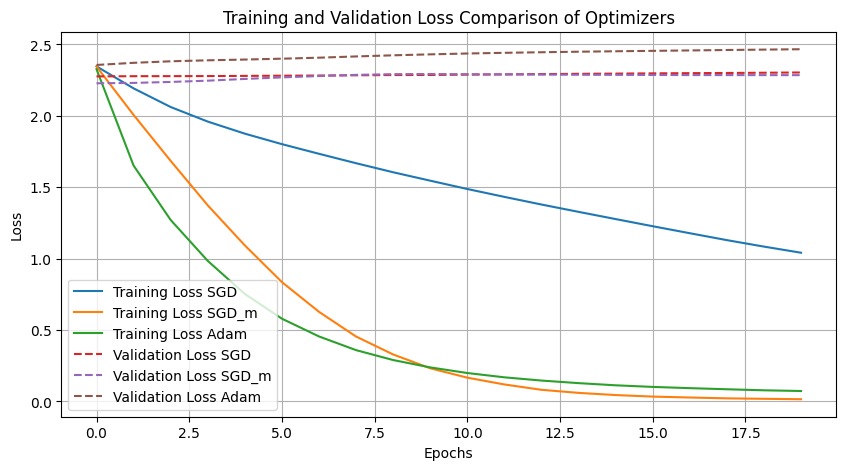

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
for keys, values in all_train_loss.items():
    ax.plot(values, label=f'Training Loss {keys}')
for keys, values in all_val_loss.items():
    ax.plot(values, label=f'Validation Loss {keys}', linestyle='--')

ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss Comparison of Optimizers')
ax.legend()
plt.grid(True)
plt.show()

The lowest loss and fastest method looks SGD with momentum and Adam while SGD looks slightly flat and took more time (from the curve).

All three models are overfitted can see from the validation line.

ADAM takes twice the GPU memory than the SGD as it keeps in track of two parameters to update the learning rate according to the calculated gradient. For smaller dataset the adam optimizer is effective interms of fastest and smoother curve on loss calculated.

Training stability: add nn.BatchNorm1d after your
hidden layer OR nn.Dropout(0.3). Re-train and report the effect on validation
loss. Explain why the technique produces the effect you observe.

In [28]:
import torch.nn as nn
import torch.optim as optim
from torch.autograd import no_grad # Assuming no_grad is still used or needs to be imported

# Define the neural network architecture with optional Batch Normalization and Dropout
class FinalNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, is_batchnorm=False, is_dropout=False):
    super(FinalNN, self).__init__()
    # First linear layer mapping input to hidden size
    self.layer1 = nn.Linear(input_size, hidden_size)
    # Second linear layer mapping hidden size to output size
    self.layer2 = nn.Linear(hidden_size, output_size)

    # Store boolean flags for batch normalization and dropout
    self.is_batchnorm = is_batchnorm
    self.is_dropout = is_dropout

    # Initialize Batch Normalization layer if enabled
    # BatchNorm1d normalizes across the features, hidden_size here is the number of features
    if self.is_batchnorm:
        self.bn_layer = nn.BatchNorm1d(hidden_size)
    # Initialize Dropout layer if enabled
    if self.is_dropout:
        self.dropout_layer = nn.Dropout(0.3) # Dropout rate of 0.3

  def forward(self, x):
    # Pass through the first linear layer
    x = self.layer1(x)
    # Apply Batch Normalization if enabled (typically before activation for better performance)
    if self.is_batchnorm:
        x = self.bn_layer(x)
    # Apply ReLU activation function
    x = torch.relu(x)
    # Apply Dropout if enabled
    if self.is_dropout:
        x = self.dropout_layer(x)
    # Pass through the second linear layer to get final output
    x = self.layer2(x)
    return x

  def train_and_evaluate(self, train_loader, val_loader, criterion, optimizer):
    no_of_epoch = 20 # Number of training epochs
    train_losses = [] # List to store training loss per epoch
    val_losses = []   # List to store validation loss per epoch

    for epoch in range(no_of_epoch):
        # Set the model to training mode
        self.train()
        train_epoch_loss = 0.0
        for inputs, labels in train_loader:
            # Move data to the appropriate device (CPU/GPU)
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass: compute predicted outputs by passing inputs to the model
            output = self(inputs)
            # Calculate the loss
            loss = criterion(output, labels)

            # Zero the gradients of all optimized parameters
            optimizer.zero_grad()
            # Backward pass: compute gradient of the loss with respect to model parameters
            loss.backward()
            # Perform a single optimization step (parameter update)
            optimizer.step()

            # Accumulate training loss, scaled by batch size
            train_epoch_loss += loss.item() * inputs.size(0)
        # Calculate average training loss for the epoch
        train_epoch_loss /= len(train_loader.dataset)
        train_losses.append(train_epoch_loss)

        # Set the model to evaluation mode
        self.eval()
        val_epoch_loss = 0.0
        # Deactivate autograd for validation to save memory and computations
        with no_grad():
            for inputs, labels in val_loader:
                # Move data to the appropriate device
                inputs, labels = inputs.to(device), labels.to(device)
                # Forward pass
                output = self(inputs)
                # Calculate the loss
                loss = criterion(output, labels)

                # Accumulate validation loss, scaled by batch size
                val_epoch_loss += loss.item() * inputs.size(0)

            # Calculate average validation loss for the epoch
            val_epoch_loss /= len(val_loader.dataset)
            val_losses.append(val_epoch_loss)

        # Optional: Print epoch-wise loss (commented out for cleaner output during multiple runs)
        # print(f"Epoch {epoch+1}/{no_of_epoch}, Train Loss: {train_epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}")

    return train_losses, val_losses

# Helper function to train a model with specified regularization and optimizer
def train_model(model_instance, optimizer_class, lr, is_batchnorm=False, is_dropout=False):
    # Instantiate the model with appropriate flags
    model = FinalNN(INPUT_SIZE, 20, 10, is_batchnorm=is_batchnorm, is_dropout=is_dropout)
    model.to(device)

    # Define the loss function (CrossEntropyLoss is standard for multi-class classification)
    criterion = nn.CrossEntropyLoss()
    # Initialize the optimizer for the current model instance
    optimizer = optimizer_class(model.parameters(), lr=lr)

    # Train and evaluate the model
    train_loss, val_loss = model.train_and_evaluate(train_loader, val_loader, criterion, optimizer)
    return train_loss, val_loss

# --- Training Setup ---

# 1. Standard Model (No BatchNorm, No Dropout)
standard_train_loss, standard_val_loss = train_model(None, optim.Adam, 0.001, is_batchnorm=False, is_dropout=False)

# 2. Model with Batch Normalization
batchnorm_train_loss, batchnorm_val_loss = train_model(None, optim.Adam, 0.001, is_batchnorm=True, is_dropout=False)

# 3. Model with Dropout
dropout_train_loss, dropout_val_loss = train_model(None, optim.Adam, 0.001, is_batchnorm=False, is_dropout=True)


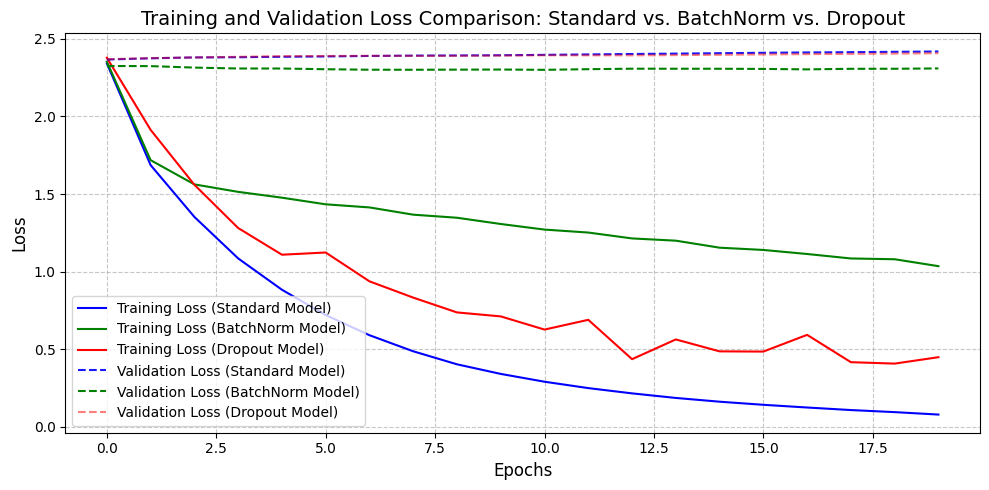

In [35]:
# Initialize a figure and an axes object for plotting
fig, ax = plt.subplots(figsize=(10, 5)) # Increased figure size for better visibility

# Plotting training losses
ax.plot(standard_train_loss, label='Training Loss (Standard Model)', color='blue', linestyle='-')
ax.plot(batchnorm_train_loss, label='Training Loss (BatchNorm Model)', color='green', linestyle='-')
ax.plot(dropout_train_loss, label='Training Loss (Dropout Model)', color='red', linestyle='-')

# Plotting validation losses
ax.plot(standard_val_loss, label='Validation Loss (Standard Model)', color='blue', linestyle='--' , alpha=0.9)
ax.plot(batchnorm_val_loss, label='Validation Loss (BatchNorm Model)', color='green', linestyle='--')
ax.plot(dropout_val_loss, label='Validation Loss (Dropout Model)', color='red', linestyle='--',  alpha=0.5)

# Set labels and title for the plot
ax.set_xlabel('Epochs', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training and Validation Loss Comparison: Standard vs. BatchNorm vs. Dropout', fontsize=14)

# Add a legend to distinguish the plots
ax.legend(loc='lower left', fontsize=10)

# Add a grid for better readability of values
ax.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Display the plot
plt.show()